# Post-processing chain

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [204]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = '/lhome/nicholas/software/workdir/mocka'
idir = f'{path}/input'

## *Example of photometry*

In [4]:
# Set up a Simulation object
sim = Simulation("output_photometry", outputDir=os.getcwd())

# Download files from KUL FTP site:
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
# ut.downloadFromFTP(filename="varsource_gdor.txt",  outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_algol.txt", outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_ap.txt",    outputDir=os.getcwd(), server='plato')

# Load variable source files
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFile2 = inputDir + "/varsource_ap.txt"

# Load files
var0 = np.loadtxt(variableSourceFile0)
var1 = np.loadtxt(variableSourceFile1)
var2 = np.loadtxt(variableSourceFile2)

<IPython.core.display.Javascript object>


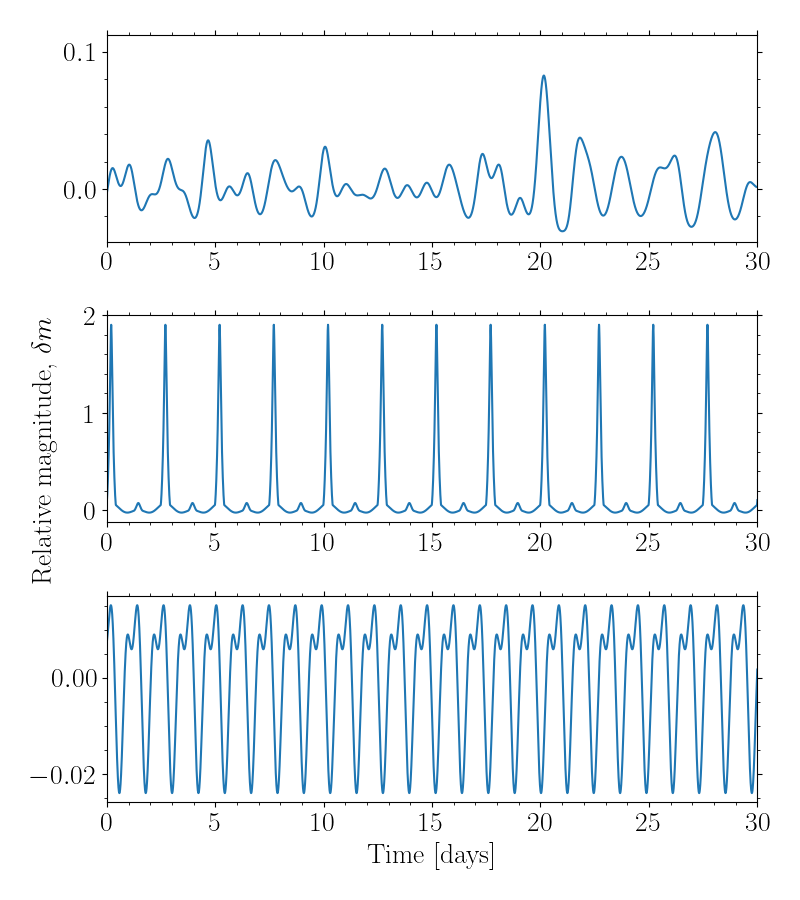

In [5]:
# Show noise-less light curves
fig, ax = plt.subplots(3, 1, figsize=(8,9))
for i, var in zip(range(3), [var0, var1, var2]):
    time = var[:,0]/86400
    ax[i].plot(time, var[:,1])
    ax[i].set_xlim(time[0], 30)
fig.text(0.04, 0.5, 'Relative magnitude, $\delta m$', va='center', rotation='vertical')
ax[2].set_xlabel('Time [days]')
plt.tight_layout()

In [6]:
# Automatic catalogue file creation
starID = [0, 1, 2]
variableSourceFiles = [variableSourceFile0, variableSourceFile1, variableSourceFile2]
variableSourceList  = os.getcwd() + "/varlist_photometry.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Select subfield size and location
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([3.0, 2.1, 4.3]) + sim["SubField/ZeroPointRow"]
col = np.array([3.0, 1.8, 5.2]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0, 12.0, 11.0])

# Automatic catalogue file creation
starcatFile = os.getcwd() + "/starcat_photometry.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Automatic photometry file creation
starID = [0]
photometryFile = os.getcwd() + "/photometry_example1.txt"
sim.createPhotometryFile(starID, photometryFile)

# Turn off saving 
sim.turnOffAllOutput()
sim["Sky/IncludeCosmicsInSubField"]    = False

# Control HDF5
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Activate photometry
sim["Photometry/IncludePhotometry"] = True
sim["Photometry/TargetFileName"]    = photometryFile

<IPython.core.display.Javascript object>


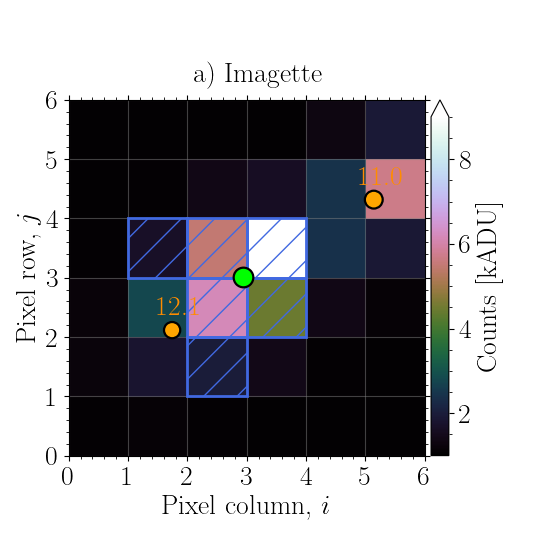

In [8]:
# Show imagette
sim["ObservingParameters/NumExposures"] = 1
f0 = sim.run(removeOutputFile=True)
fig, ax = f0.showImage(imgScale="percentile", clip=1, fontSize=20, count='kADU',
                       figsize=(5.5,5.5), showStarPositions='PIC', origin='lower',
                       colorBar=True, showGrid=True, showMaskOfStarID=0)
fig.text(0.47, 0.85, 'a) Imagette', ha='center')
# Save figure
fig.savefig(f'{fdir}/Imagette.png', bbox_inches='tight', dpi=200)

In [9]:
# Run the simulation
sim["ObservingParameters/NumExposures"] = int(10*86400/25.)
f1 = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:01:43.497739 [hh:mm:ss]


<IPython.core.display.Javascript object>


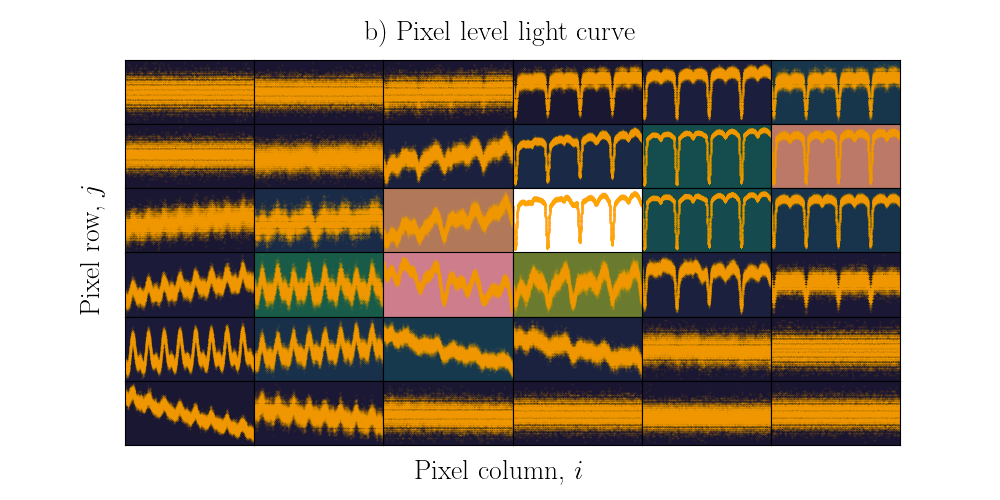

In [11]:
fig = f1.showPixelLevelLightCurve()
fig.text(0.5, 0.92, 'b) Pixel level light curve', ha='center')
# Save figure
fig.savefig(f'{fdir}/PixelLevelLightCurve.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


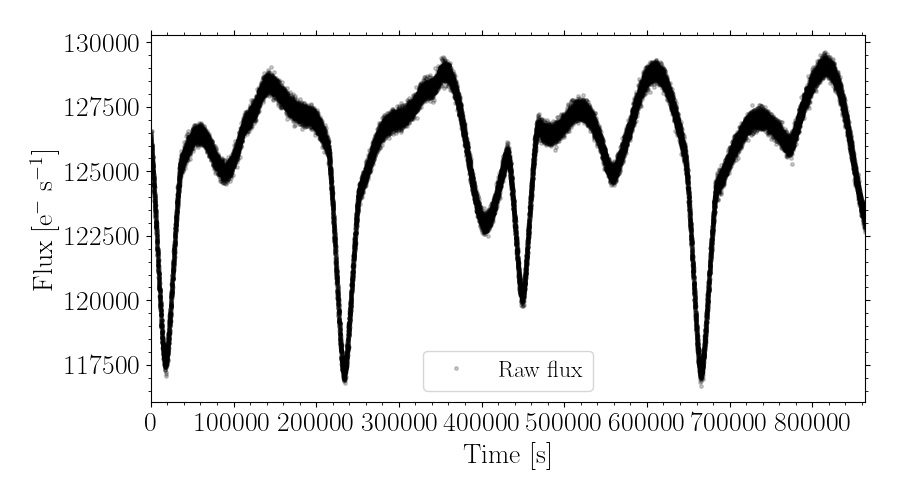

In [12]:
f1.plotLightCurve(0);

## *Show light curve*

In [176]:
lc = LightCurve(f'{path}/test_vsc/000000600/000000600_Ncam2.1_Q1.ftr')

In [177]:
lc.varsource()

,time,mag,flux
0,0.0,0.109287,-0.029632
1,25.0,0.109278,-0.029624
2,50.0,0.109270,-0.029617
3,75.0,0.109261,-0.029609
4,100.0,0.109253,-0.029601
...,...,...,...
2522875,63071875.0,0.085976,-0.008572
2522876,63071900.0,0.085977,-0.008574
2522877,63071925.0,0.085979,-0.008576
2522878,63071950.0,0.085981,-0.008577


<IPython.core.display.Javascript object>


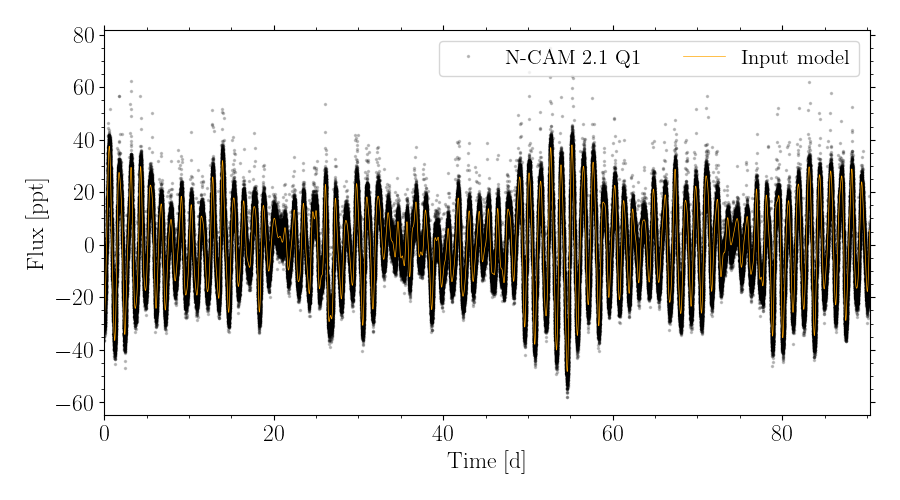

In [181]:
lc.plot(flux_unit='ppt', input_model=True);

## Test of single quarter with mask-updates

In [ ]:
# inputFileGap = f'{idir}/instrumentGap.tab'
# dg = pd.read_feather(inputFileGap)
# dg.iloc[0]

In [21]:
Q = 2
lc = LightCurve(f'{path}/test_local/000000606_Ncam1.1_Q{Q}.hdf5')
sim = Simulation('test.hdf5') 
beginExposureNr = int(315569*(Q-1))
numExposures    = 312113

In [23]:
# inputFileCCD = f'{idir}/instrumentCCD.txt'
# dt = pd.read_csv(inputFileCCD, sep=' ', names=['time', 'temp'])
# dt = dt.iloc[beginExposureNr:beginExposureNr+numExposures]
# temp = dt.temp.to_numpy()

# inputFileGap = f'{idir}/instrumentGap.tab'
# dg = pd.read_feather(inputFileGap)
# tdur = dg.td.iloc[0] / 86400

# tempNominal   = sim['CCD/NominalOperatingTemperature']
# gainCCD       = sim['CCD/Gain/RefValueRight']
# gainFEE       = sim['FEE/Gain/RefValueRight']
# gainStability = sim['FEE/Gain/Stability']

# df = lc.correct_gain(temp, tdur, tempNominal, gainCCD, gainFEE, gainStability, replace=True, plot=True)

In [ ]:
df = lc.detrend(model='poly', degree=1, replace=True, plot=True)

In [ ]:
df = lc.stitch(medpoint=1000, replace=True, plot=True)

In [ ]:
df = lc.clip(model='wotan', replace=True, plot=True, flux_unit='ppt')

In [ ]:
inputFileGap = f'{idir}/instrumentGap.tab'
dg = pd.read_feather(inputFileGap)
# dg = dg.iloc[beginExposureNr:beginExposureNr+numExposures]
dg

## Test light curves merging

In [220]:
lcs = LightCurve(f'{path}/test_vsc/000000600_withTED', 'multi')

In [221]:
lc = lcs.merge(flux_group_mean=True, binsize=600)

<IPython.core.display.Javascript object>


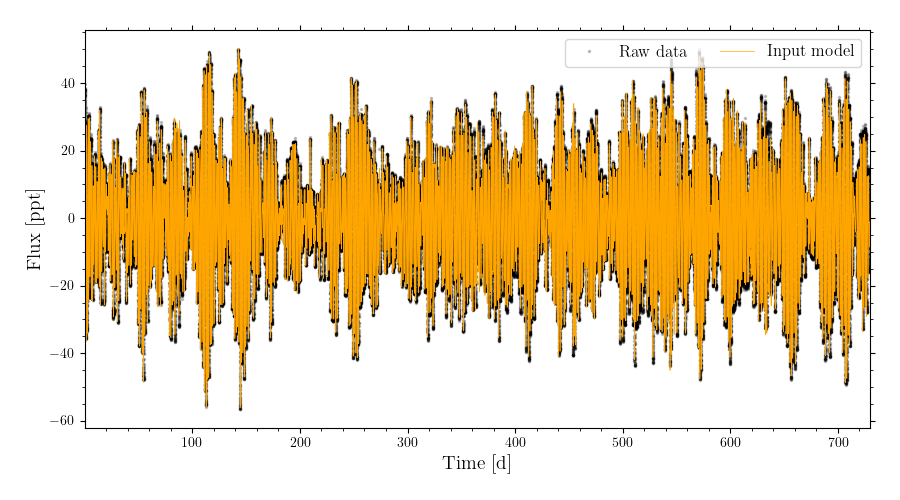

In [222]:
lc.plot(input_model=True, flux_unit='ppt', figsize=(9,5));

In [223]:
df = lc.data()
df = df.dropna(subset=['flux'])
df['flux_err'] = np.ones_like(df.flux)
df.time /= 86400
df

,time,flux,flux_err
0,0.003472,0.971663,1.0
1,0.010417,0.971378,1.0
2,0.017361,0.971836,1.0
3,0.024306,0.972336,1.0
4,0.031250,0.972255,1.0
...,...,...,...
105040,729.452763,0.999750,1.0
105041,729.459708,0.999934,1.0
105042,729.466652,1.000358,1.0
105043,729.473597,1.000617,1.0


In [224]:
df.flux.isna().sum()

0

In [225]:
file = f'{path}/lc_final_000000600.dat'
df.to_csv(file, sep=' ', index=False, header=False)

## Test frequency extraction with STARSHADOW

With a PLATOnium conda environment activated, first install software using
```
pip install git+https://github.com/LucIJspeert/star_shadow
```
Open the file needed to compile the `numba` code
```
$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Replace the line:
```
data_dir = script_dir.replace('star_shadow', 'data') 
```
with 
```
data_dir = os.path.join(script_dir, 'data')
```
Compile the code with:
```
python $CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Now the code can be used.

In [226]:
import star_shadow as ss

In [227]:
ss.analyse_lc_from_file(file, stage='freq', method='fitter', save_dir=f'{path}/final', 
                        overwrite=True, verbose=True)

2024-01-29 18:07:14 - INFO - Start of analysis


Looking for frequencies
N_f= 0, BIC= -554299.88 (delta= N/A) - start extraction
Edge of frequency range 0.10149325203573901 at position 30 during extraction phase 1.= 0.0000545979


SystemError: CPUDispatcher(<function scargle at 0x7f8fda863ca0>) returned a result with an error set